In [1]:
from scr.SPM import Solid_Phase
from scr.pinn import FFNN
from scr.utils import load_params

import ipywidgets as widgets
import matplotlib.pyplot as plt

import pybamm
import torch

In [2]:
parameters = load_params()

model = FFNN(2, 1)
PINN_pos = Solid_Phase(model, parameters, electrode="pos")
PINN_pos.load_model("models/positive.pt")
PINN_neg = Solid_Phase(model, parameters, electrode="neg")
PINN_neg.load_model("models/negative.pt")

param = pybamm.ParameterValues("Chen2020")
PBM_model = pybamm.lithium_ion.SPM()
experiment = pybamm.Experiment(["Discharge at 1C for 10000 seconds or until 2.5 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1)

x = solution["x [m]"].entries[:, 0]

c_s_n = solution["Negative particle concentration"]
c_s_p = solution["Positive particle concentration"]
r_n = solution["r_n [m]"].entries[:, 0, 0]
r_p = solution["r_p [m]"].entries[:, 0, 0]

In [ ]:
def plot_concentrations(t):

    bc_sample_r = torch.linspace(0., 1., 1000)
    bc_sample_t = torch.ones_like(bc_sample_r)
    bc_sample = torch.stack([bc_sample_t, bc_sample_r]).t()

    c_pinn_p = PINN_pos(bc_sample)
    c_pinn_n = PINN_neg(bc_sample)

    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    (plot_c_n,) = ax1.plot(
        r_n, c_s_n(r=r_n, t=t * 3600, x=x[0])
    )  # can evaluate at arbitrary x (single representative particle)
    (plot_c_p,) = ax2.plot(
        r_p, c_s_p(r=r_p, t=t * 3600, x=x[-1])
    )  # can evaluate at arbitrary x (single representative particle)

    (plot_c_n,) = ax1.plot(
        bc_sample_r.detach().numpy(), c_pinn_p.detach().numpy()
    )  # can evaluate at arbitrary x (single representative particle)
    (plot_c_p,) = ax2.plot(
        bc_sample_r.detach().numpy(), c_pinn_n.detach().numpy()
    )  # can evaluate at arbitrary x (single representative particle)
    ax1.set_ylabel("Negative particle concentration")
    ax2.set_ylabel("Positive particle concentration")
    ax1.set_xlabel(r"$r_n$ [m]")
    ax2.set_xlabel(r"$r_p$ [m]")
    ax1.set_ylim(0, 1)
    ax2.set_ylim(0, 1)
    plt.show()

widgets.interact(
    plot_concentrations, t=widgets.FloatSlider(min=0, max=1, step=10, value=0)
)

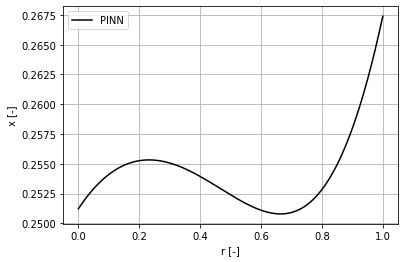

In [3]:

bcs_sample_r = torch.linspace(0., 1., 1000)
bcs_sample_t = torch.zeros_like(bcs_sample_r)
bcs_sample = torch.stack([bcs_sample_t, bcs_sample_r]).t()
c_bcs = PINN_pos(bcs_sample)

plt.figure()
plt.grid("on")
plt.plot(bcs_sample_r.detach().numpy(), c_bcs.detach().numpy(), "k", label="PINN")
#plt.plot(t, pos_SPM_r1, "r", label="Pybamm")
plt.legend()
plt.xlabel("r [-]")
plt.ylabel("x [-]")
plt.show()

## Residual plots

In [8]:
import numpy as np

num = 1000.

t_test = (torch.arange(0, num, dtype=torch.float, requires_grad=True)/num)[::10]
r_rand = (torch.arange(0, num, dtype=torch.float, requires_grad=True)/num)[::10]

t_new, r_new = torch.meshgrid(t_test, r_rand)
pos = np.zeros_like(t_new.detach().numpy())
neg = np.zeros_like(t_new.detach().numpy())

pos_dcdt = np.zeros_like(t_new.detach().numpy())
neg_dcdt = np.zeros_like(t_new.detach().numpy())
pos_dcdr = np.zeros_like(t_new.detach().numpy())
neg_dcdr = np.zeros_like(t_new.detach().numpy())

for i, (t, r) in enumerate(zip(t_new, r_new)):

  residuals = PINN_pos.compute_residuals(torch.stack((t, r)).t())
  pos[i, :] = np.abs(residuals.detach().numpy())
  gradients = PINN_pos.compute_gradients(torch.stack((t, r)).t())
  pos_dcdt[i, :] = np.abs(gradients[:,0].detach().numpy())
  pos_dcdr[i, :] = np.abs(gradients[:,1].detach().numpy())
  
  residuals = PINN_neg.compute_residuals(torch.stack((t, r)).t())
  neg[i, :] = np.abs(residuals.detach().numpy())
  gradients = PINN_neg.compute_gradients(torch.stack((t, r)).t())
  neg_dcdt[i, :] = np.abs(gradients[:,0].detach().numpy())
  neg_dcdr[i, :] = np.abs(gradients[:,1].detach().numpy())

In [12]:
def plot_area(points, style, cmap_label):
    plt.subplots(figsize=(7,3), tight_layout=True)
    plot = plt.pcolormesh(t_new.detach().numpy(), r_new.detach().numpy(), points, cmap=style, shading='gouraud')
    cbar = plt.colorbar(plot)
    plt.contour(t_new.detach().numpy(), r_new.detach().numpy(), points, 10, colors='gray')
    plt.ylabel('$r$')
    plt.xlabel('$t$ [h]')
    cbar.set_label(cmap_label)
    # plt.savefig('/content/drive/MyDrive/Datos/con_PINN_pos.png')
    plt.show()

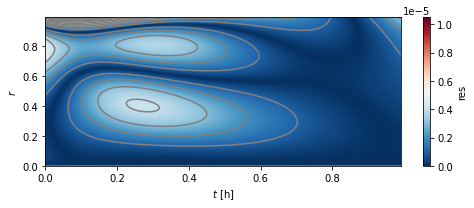

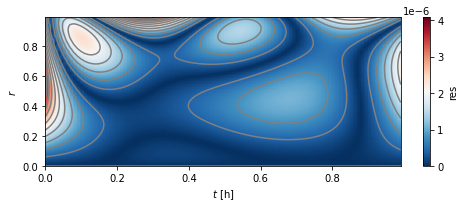

In [13]:
plot_area(pos, 'RdBu_r', 'res')
plot_area(neg, 'RdBu_r', 'res')

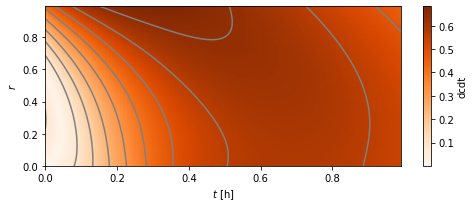

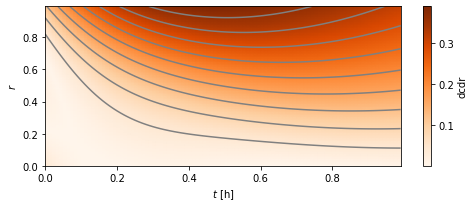

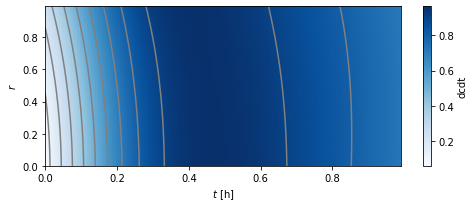

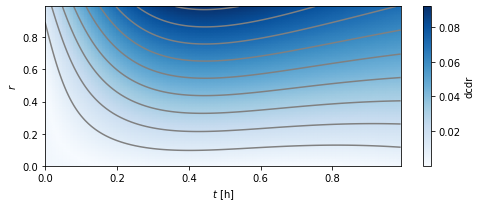

In [14]:
plot_area(pos_dcdt, 'Oranges', 'dcdt')
plot_area(pos_dcdr, 'Oranges', 'dcdr')
plot_area(neg_dcdt, 'Blues', 'dcdt')
plot_area(neg_dcdr, 'Blues', 'dcdr')